In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy import stats
import seaborn as sns
from scipy.stats import skew, kurtosis, chi2_contingency

## <span style="color:black;"><strong>Parte 1: Análisis Univariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>

A partir de una muestra simulada de ingresos, calcula la **media, mediana y moda**, y luego a interpretarlas.

1. Usa el número base `528310` (debes reemplazarlo con los últimos 6 dígitos de tu documento de identificación).  
2. Con este número genera una semilla (`np.random.seed`) para que los resultados sean reproducibles.  
3. Los ingresos se simulan con una distribución normal:  
   - Media teórica: `(base % 10) + 2`  
   - Desviación estándar: `2`  
   - Tamaño de muestra: `30`  
4. Los valores negativos se reemplazan por cero (pues los ingresos no pueden ser negativos).  
5. Grafica tus resultados (ver imagen de ejemplo)

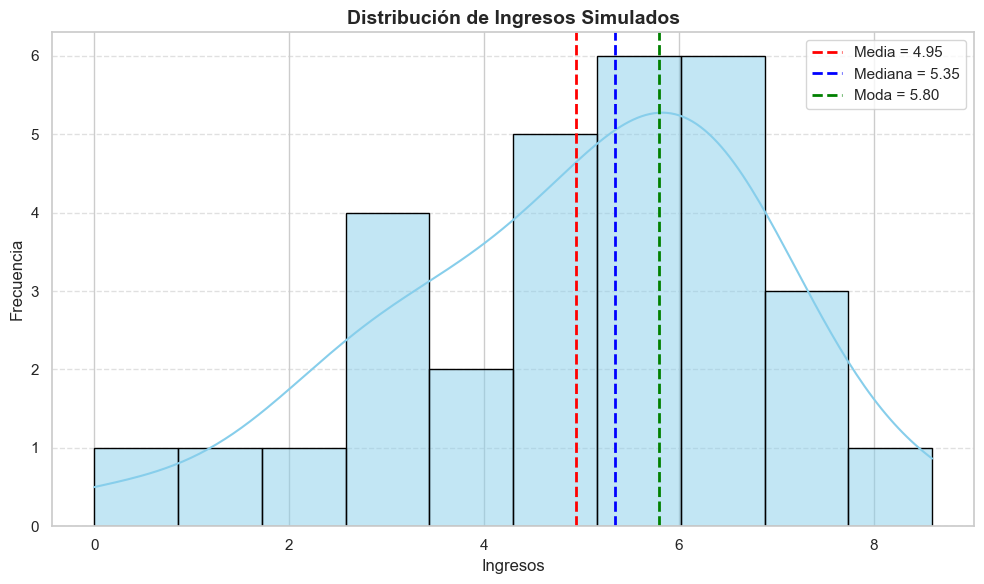

# **Nuestra solución -------------------------------------------------------------**\

In [2]:
# Creación: semilla para reproducibilidad
base = 969464
np.random.seed(base)

datosa_1 = np.random.normal(loc=((base % 10) + 2), scale=2, size=30)
datosa = np.round(datosa_1).astype(int)

# Cálculo de medidas de tendencia central

media = np.mean(datosa)
mediana = np.median(datosa)
moda = stats.mode(datosa, keepdims=True)[0][0]

datosa

array([ 8,  2,  7,  7,  7, 10,  6,  6,  6,  7,  5,  5,  8,  5,  8,  7,  5,
        5,  6,  6,  8,  7,  7,  6,  4,  5,  7, 10, 10,  5])

Medidas de tendencia central:
Media:   6.5
Mediana: 6.5
Moda:    7


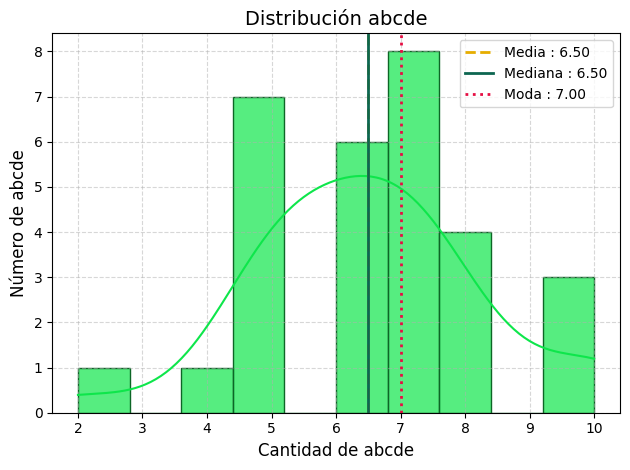

In [3]:
# Resultados y gráficas
print("Medidas de tendencia central:")
print(f"Media:   {media}")
print(f"Mediana: {mediana}")
print(f"Moda:    {moda}")

sns.histplot(
    datosa,
    bins=10,             # Un poco más de detalle
    kde=True,            # Agregamos la línea para ver la forma
    color='#0EE64B',     # Tu color base
    edgecolor='#0D6626',   # Color del borde que delimita las barras
    linewidth=1,       # Grosor del borde
    alpha=0.7            # Transparencia (0 es invisible, 1 es sólido)
)
plt.title("Histograma - Distribución Normal")
plt.xlabel("Valores")
plt.ylabel("Frecuencia")

plt.axvline(media, color='#E6AD00', linestyle='--', linewidth=2, label=f'Media : {media:.2f}')
plt.axvline(mediana, color='#0D6650', linestyle='-', linewidth=2, label=f'Mediana : {mediana:.2f}')
plt.axvline(moda, color='#E60E43', linestyle=':', linewidth=2, label=f'Moda : {moda:.2f}')

plt.title("Distribución abcde", fontsize=14)
plt.xlabel("Cantidad de abcde", fontsize=12)
plt.ylabel("Número de abcde", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()

plt.show()

### <span style="color:#2F749F;"><strong>Ejercicio 2: Cálculo de medidas de dispersión</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza qué tan dispersos están los datos respecto a su media. Calcula:
1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

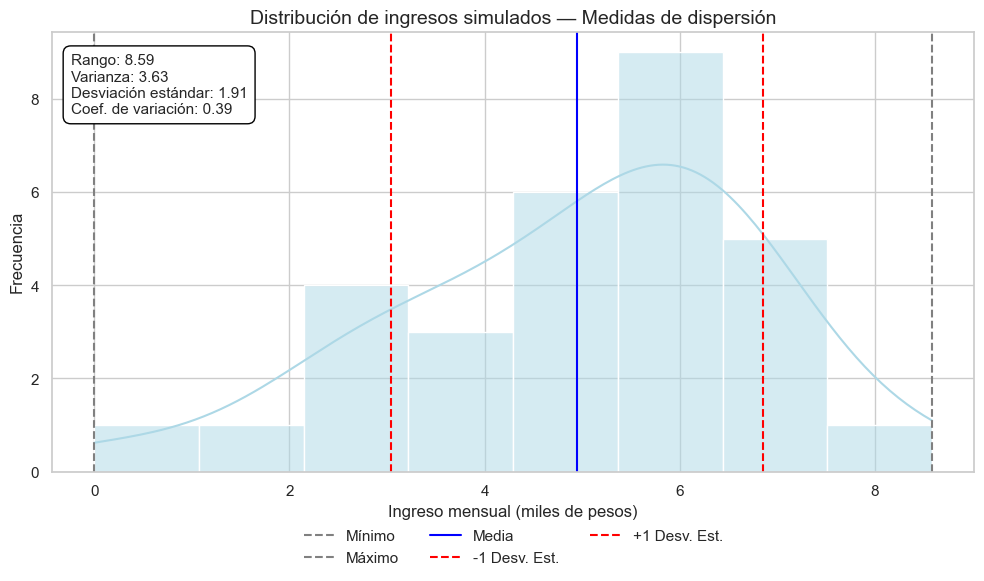

# **Nuestra solución -------------------------------------------------------------**

Rango : 8


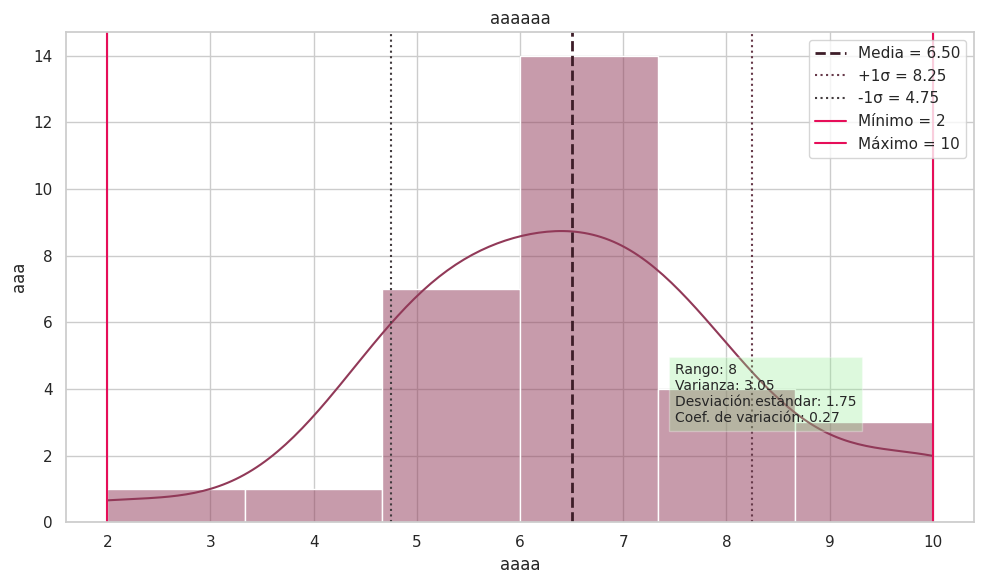

In [4]:
#Rango
minimo = np.min(datosa)
maximo = np.max(datosa)

rango = maximo - minimo

print(f"Rango : {rango}")

#Varianza
varianza = np.var(datosa)

#Desviación
desviacion = np.std(datosa)

#Coeficiente de variación
coef_var = desviacion / media

# Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(datosa, bins=6, kde=True, color='#913958')

plt.axvline(media, color='#3D1D28', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='#663949', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='#423B3E', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')
plt.axvline(minimo, color='#E60E59', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo}')
plt.axvline(maximo, color='#E60E59', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo}')

plt.title("aaaaaa")
plt.xlabel("aaaa")
plt.ylabel("aaa")
plt.legend()

# Recuadro con medidas
texto = (
    f"Rango: {rango}\n"
    f"Varianza: {varianza:.2f}\n"
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}"
)
plt.text(7.5, 3, texto, bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=10)

plt.tight_layout()
plt.show()


### <span style="color:#2F749F;"><strong>Ejercicio 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal (ver la imagen de ejemplo)

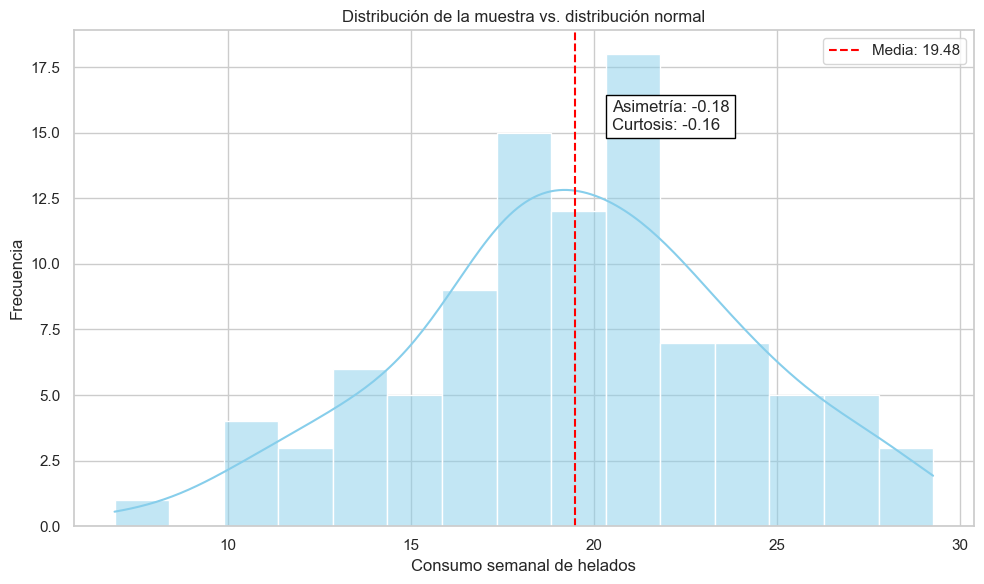


# **Nuestra solución -------------------------------------------------------------**

Asimetría: 0.0750948635165729
Curtosis: 3.425154528352594


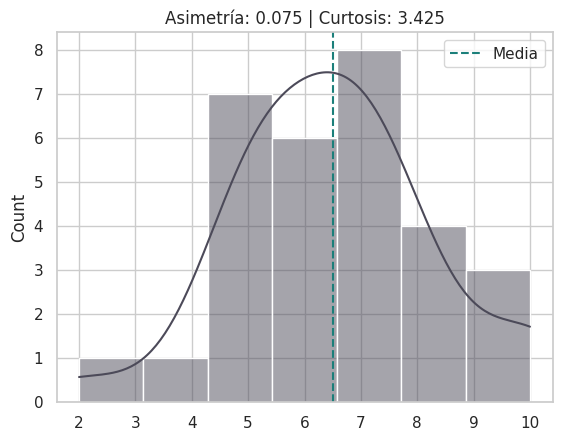

In [5]:
asimetria = stats.skew(datosa)
curtosis = stats.kurtosis(datosa, fisher = False)

print("Asimetría:", asimetria)
print("Curtosis:", curtosis)

sns.histplot(datosa, kde=True, color = '#4C4A59')
plt.title("Distribución con KDE")
plt.axvline(np.mean(datosa), color='#1B7F7A', linestyle='--', label='Media')

plt.title(f"Asimetría: {asimetria:.3f} | Curtosis: {curtosis:.3f}")
plt.legend()
plt.show()

### <span style="color:#2F749F;"><strong>Ejercicio 4: Cálculo de medidas de percentiles</strong></span>

A partir de la muestra generada en el Ejercicio 1, calcula los percentiles de tus datos. Calcula:
1. Percentiles
2. Deciles
3. Cuartiles
4. Grafica los anteriores percentiles calculados, sobre la distribución de tus datos (ver la imagen de ejemplo)

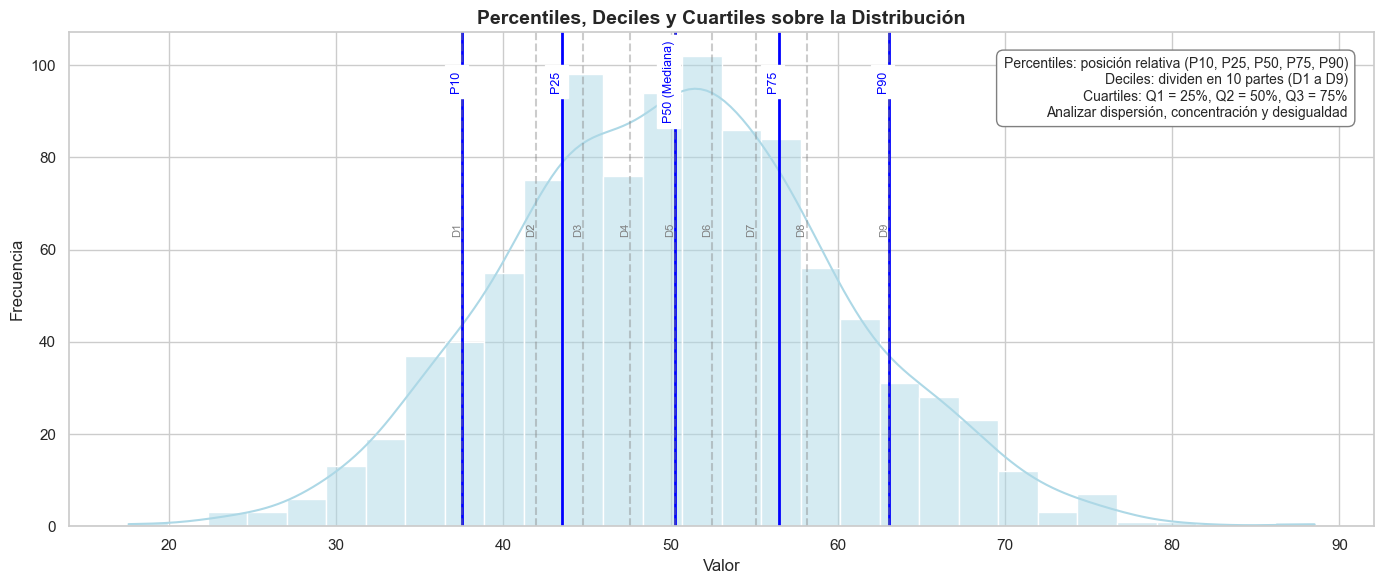

# **Nuestra solución -------------------------------------------------------------**

Text(0.98, 0.95, 'Percentiles → dividen en 100 partes\nDeciles → dividen en 10 partes (D1 a D9)\nCuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n')

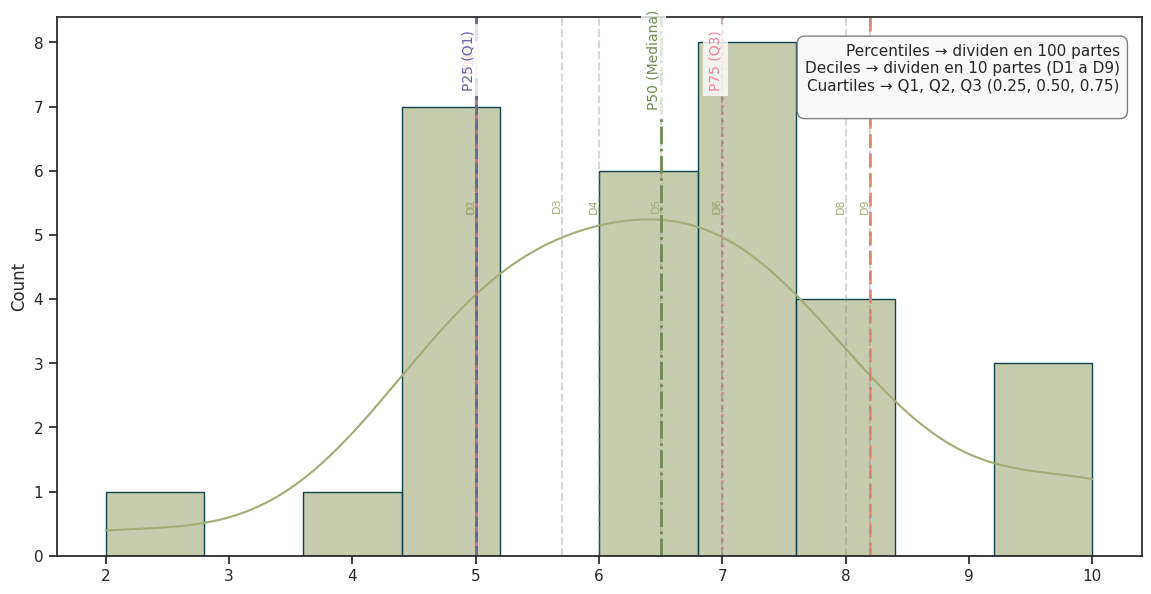

In [6]:
sns.set_theme(style = "ticks")

percentiles = {
    'P10': {'valor': np.percentile(datosa, 10), 'color': '#D9628D', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(datosa, 25), 'color': '#6260A6', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(datosa, 50), 'color': '#6D8C4F', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(datosa, 75), 'color': '#F2809F', 'linestyle': ':'},
    'P90': {'valor': np.percentile(datosa, 90), 'color': '#F28972', 'linestyle': (0, (5, 2))}
}

deciles = {f'D{i}': np.percentile(datosa, i * 10) for i in range(1, 10)}

plt.figure(figsize=(14, 7))
sns.histplot(datosa, kde=True, color='#A3AB78', bins=10, edgecolor="#10454F", alpha=0.6)

for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    plt.text(props['valor'], plt.ylim()[1]*0.92, etiqueta,
             rotation=90, color=props['color'], fontsize=10,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.65, etiqueta,
             rotation=90, color='#A3AB78', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

texto = (
    "Percentiles → dividen en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Q1, Q2, Q3 (0.25, 0.50, 0.75)\n")
plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))


### <span style="color:#2F749F;"><strong>Ejercicio 5: Análisis de correlación</strong></span>

En esta segunda parte, genera **dos variables** a partir de tú número de cédula y realiza un análisis **bivariado** para calcular la relación entre ellas.

1. Use los **6 últimos dígitos** de su cédula como base (similar al Ejercicio 1).  
2. Genere dos variables aleatorias (ejemplo: `ingresos` y `gastos`) con distribución normal, usando esa base como **semilla reproducible**.  
3. Calcule los coeficientes de correlación de **Pearson** y **Spearman**.
4. Grafique las variables analizadas (ver la imagen de ejemplo)
5. Interprete los resultados.  

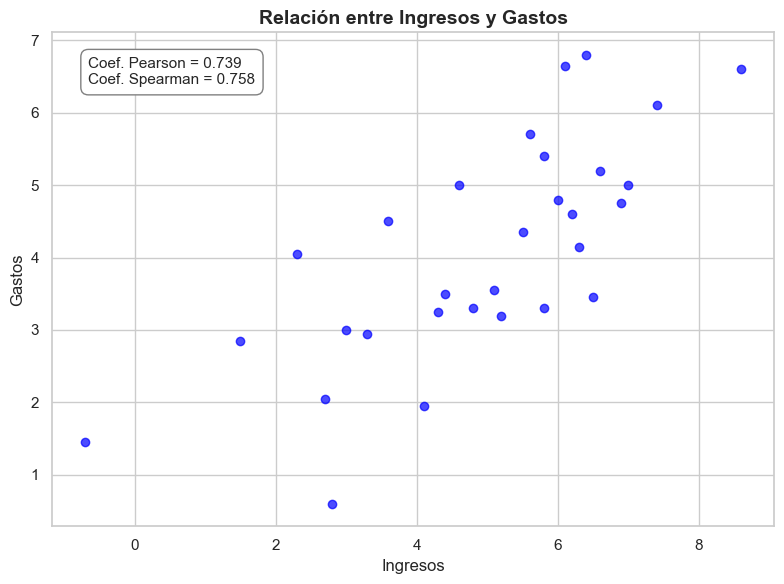

# **Nuestra solución  -------------------------------------------------------------**

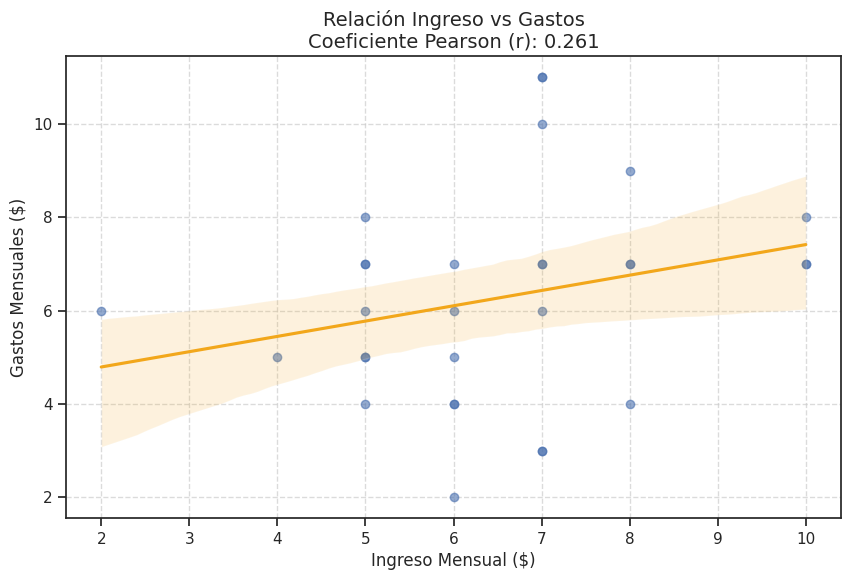

Coeficiente de Correlación: 0.2615
Significancia (p-valor): 1.6280e-01


In [10]:
np.random.seed(base)

ingreso_1 = np.random.normal(((base % 10) + 2), scale=2, size=30)
ingreso = np.round(ingreso_1).astype(int)

gastos_1 = np.random.normal(((base % 10) + 2), scale=2, size=30)
gastos = np.round(gastos_1).astype(int)

r1,_= pearsonr(ingreso, gastos)

plt.figure(figsize=(10, 6))
sns.regplot(x=ingreso, y=gastos, scatter_kws={'alpha':0.6}, line_kws={'color':'#F2A71B'})

plt.title(f"Relación Ingreso vs Gastos\nCoeficiente Pearson (r): {r1:.3f}", fontsize=14)
plt.xlabel("Ingreso Mensual ($)")
plt.ylabel("Gastos Mensuales ($)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"Coeficiente de Correlación: {r1:.4f}")
print(f"Significancia (p-valor): {_:.4e}")

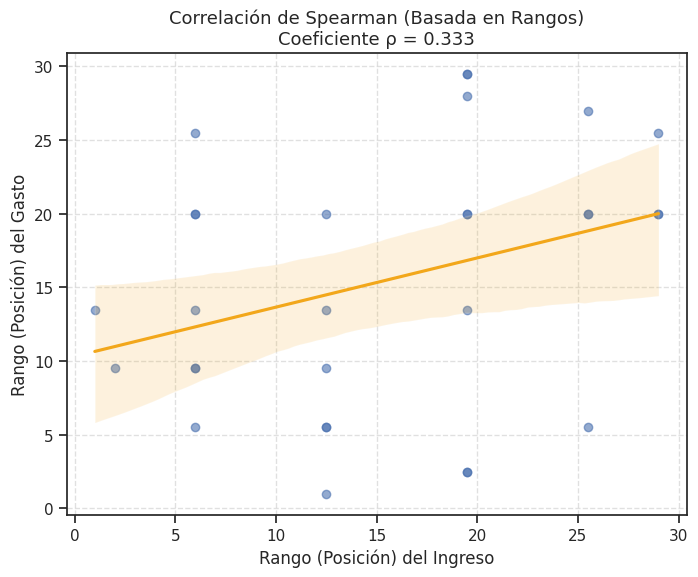

Coeficiente de Spearman (rho): 0.3326
Coeficiente p_value: 0.0726


In [11]:
#Spearman
#Convertir a Series de Pandas para usar .rank()

s_ingreso = pd.Series(ingreso).rank()
s_gastos = pd.Series(gastos).rank()

#Calcular los rangos
rangos_ingreso = pd.Series(ingreso).rank()
rangos_gastos = pd.Series(gastos).rank()

#Calcular el coeficiente de Spearman
rho, p_value = spearmanr(ingreso, gastos)

plt.figure(figsize=(8, 6))

sns.regplot(x=rangos_ingreso, y=rangos_gastos, scatter_kws={'alpha':0.6}, line_kws={'color':'#F2A71B'})

plt.title(f"Correlación de Spearman (Basada en Rangos)\nCoeficiente ρ = {rho:.3f}", fontsize=13)
plt.xlabel("Rango (Posición) del Ingreso")
plt.ylabel("Rango (Posición) del Gasto")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

print(f"Coeficiente de Spearman (rho): {rho:.4f}")
print(f"Coeficiente p_value: {p_value:.4f}")


### <span style="color:#2F749F;"><strong>Ejercicio 6: Chi-Cuadrado</strong></span>

En esta parte, analiza si existe **asociación estadística** entre dos variables categóricas simuladas a partir de tu número de cédula.

1. Usa los **6 últimos dígitos** de tu cédula como base para generar una semilla reproducible.
2. Simula una muestra de **60 personas** con dos variables categóricas:
   - `Nivel educativo`: Básico, Medio, Superior.
   - `Acceso a internet`: Sí, No.
3. Crea una **tabla de contingencia** entre ambas variables.
4. Aplica la **prueba de Chi cuadrado de independencia**.
5. Visualiza la distribución conjunta con un mapa de calor (ver la imagen de con la información de ejemplo).
6. Interpreta el resultado.

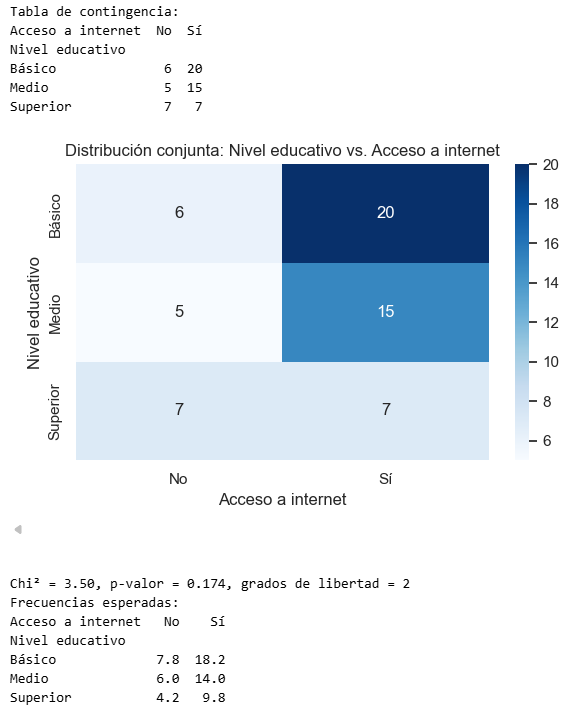

# **Nuestra solución -------------------------------------------------------------**

In [16]:
np.random.seed(base)
datos_base = np.random.normal(loc=((base % 10) + 2), scale=2, size=60)

# Generar variables categoricas

aux_nivel_educativo = ['Básico', 'Medio', 'Superior']
nivel_educativo = np.random.choice(aux_nivel_educativo, size=60)

aux_acceso_internet = ['Sí', 'No']
acceso_internet = np.random.choice(aux_acceso_internet, size=60)

# Tabla de contingencia

# Crear el DataFrame
df = pd.DataFrame({
    'Nivel educativo': nivel_educativo,
    'Acceso a internet': acceso_internet
})
tabla_contingencia = pd.crosstab(df['Nivel educativo'], df['Acceso a internet'])

# Pintar tabla de contingencia
print("Tabla de contingencia:\n")
print(tabla_contingencia)

Tabla de contingencia:

Acceso a internet  No  Sí
Nivel educativo          
Básico             12   7
Medio              10  13
Superior            7  11


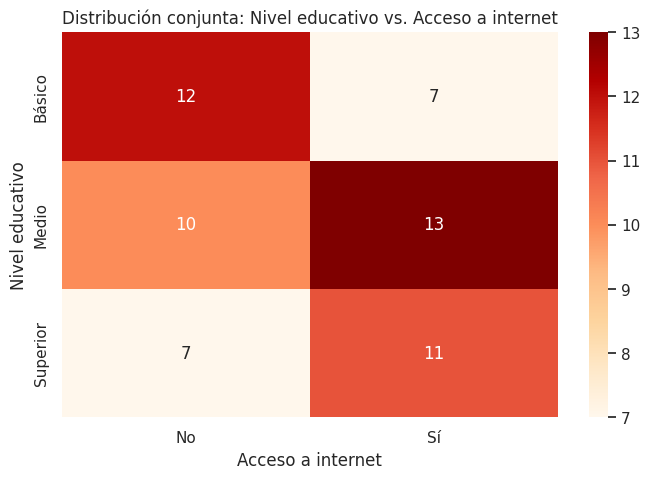


Estadístico Chi-cuadrado: 2.5321
p-valor: 0.2819
Grados de libertad: 2

Frecuencias esperadas:
Acceso a internet         No         Sí
Nivel educativo                        
Básico              9.183333   9.816667
Medio              11.116667  11.883333
Superior            8.700000   9.300000


In [34]:
chi2, p, gl, esperados = chi2_contingency(tabla_contingencia)

# Configuración del gráfico
plt.figure(figsize=(8, 5))
sns.heatmap(tabla_contingencia, annot=True, cmap='OrRd', fmt='d', cbar=True)
plt.title('Distribución conjunta: Nivel educativo vs. Acceso a internet')
plt.xlabel('Acceso a internet')
plt.ylabel('Nivel educativo')

plt.show()

# Mostrar mas info de chi-chadrado
print(f"\nEstadístico Chi-cuadrado: {chi2:.4f}")
print(f"p-valor: {p:.4f}")
print(f"Grados de libertad: {gl}\n")

print('Frecuencias esperadas:')
print(pd.DataFrame(esperados, index=tabla_contingencia.index, columns=tabla_contingencia.columns))

Interpretación de Valor P

*   Como p-valor = 0.2819 >> 0.05, entonces no se tiene evidencia suficiente para decir que las variables estan relacionadas.
*   Las variables Nivel educativo y Acceso a internet son independientes.

Interpretación de estadistico

*   El estadistico Chi-cuadrado es bajo (2.5321), lo que significa que hay pequeñas variaciones de los datos reales con lo que el azar predice.

Interpretación de Nivel de educación:
*   Básico: Personas sin internet: 12 vs Personas esperadas sin internet: 9,18 0 9.
*   Medio: Se esperaban que 11.8 o 12 personas tuvieran internet y se observan 10 personas con internet.
*   Superior: Los valores observados (7 y 11) estan muy cerca de los esperados (8.7 y 9.3)

Interpretación de Mapa de Calor:
*   Las intersecciones que presentan las mayores frecuencias observadas en la muestra son el Nivel educativo Medio con acceso a internet (13 personas), el Nivel educativo Básico sin acceso a internet (12 personas) y el Nivel educativo Superior con acceso a internet (11 personas).


## Conclusiones
*   Aunque visualmente estas celdas resaltan en el mapa de calor, al compararlas con la tabla de frecuencias esperadas (donde el azar predecía valores muy similares como 11.88, 9.18 y 9.30 respectivamente), se observa que las diferencias son mínimas.
*   Las intersecciones que presentan las mayores frecuencias observadas en la muestra son el Nivel educativo Medio con acceso a internet (13 personas), el Nivel educativo Básico sin acceso a internet (12 personas) y el Nivel educativo Superior con acceso a internet (11 personas).
*   Se concluye que el Nivel educativo y el Acceso a internet son variables independientes. Las variaciones observadas en el gráfico no son lo suficientemente fuertes como para afirmar que una variable influye sobre la otra; se deben meramente al azar.